## The Tabular Tower(XGBOOSt baseline)

### 01. Setup,Imports and Data Loading
Explanation: First, we load the .npz file created during preprocessing. We also need to extract the exact feature names from our original CSV so that when we plot the feature importances at the end, we see the actual names (like vix_zscore_21d) instead of just Feature 42.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report

print("Block 1: Loading Preprocessed Arrays...")

# 1. Load the preprocessed numpy arrays
data = np.load("preprocessed_data.npz")

X_train = data['X_train_2d']
X_val = data['X_val_2d']
X_test = data['X_test_2d']

# Load Regression Targets (Continuous Returns)
y_train_reg = data['y_train_reg']
y_val_reg = data['y_val_reg']
y_test_reg = data['y_test_reg']

# Load Classification Targets (Binary Direction)
y_train_cls = data['y_train_cls']
y_val_cls = data['y_val_cls']
y_test_cls = data['y_test_cls']

# 2. Reconstruct Feature Names for plotting later
df_features = pd.read_csv("E:/fourth_sem/nifty_ml_hybrid/datasets/processed/nifty_engineered_features.csv")
TARGET_COLS = ['target_ret_1d', 'target_dir_1d', 'target_quintile_1d']
CATEGORICAL_COLS = ['regime_200MA', 'vol_quartile_63d', 'is_monday', 'is_friday', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
CATEGORICAL_COLS = [col for col in CATEGORICAL_COLS if col in df_features.columns]
NUMERICAL_COLS = [col for col in df_features.columns if col not in ['date'] + TARGET_COLS + CATEGORICAL_COLS]

# The order matches how we created X_train_2d in preprocessing
feature_names = NUMERICAL_COLS + CATEGORICAL_COLS

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Validation Data: {X_val.shape[0]} rows")
print(f"Test Data: {X_test.shape[0]} rows")

Block 1: Loading Preprocessed Arrays...
Training Data: 1879 rows
Validation Data: 403 rows
Test Data: 403 rows


### 02.Training the XGBoost Regressor (Huber Loss)
Explanation: This model attempts to predict the exact continuous return of the NIFTY 50 tomorrow. Notice the use of reg:pseudohubererror. Standard Mean Squared Error (MSE) heavily penalizes large errors, causing the model to overfit to massive crash days. Huber loss ignores extreme outliers, forcing the model to learn the "normal" market structure.

In [9]:
print("\nBlock 2: Training XGBoost Regressor...")

# Define highly regularized hyperparameters
xgb_reg = xgb.XGBRegressor(
    objective='reg:pseudohubererror', # Crucial: Handles fat tails/outliers
    n_estimators=1000,                # Max number of trees
    learning_rate=0.01,               # Slow learning prevents overfitting
    max_depth=4,                      # Shallow trees prevent memorizing noise
    subsample=0.8,                    # Use 80% of rows per tree
    colsample_bytree=0.8,             # Use 80% of features per tree
    random_state=42,
    early_stopping_rounds=50          # Stop if validation doesn't improve for 50 rounds
)

# Fit the model and monitor both Train and Val datasets
xgb_reg.fit(
    X_train, y_train_reg,
    eval_set=[(X_train, y_train_reg), (X_val, y_val_reg)],
    verbose=100
)

# Evaluate strictly on Out-of-Sample Test Data
preds_reg = xgb_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_reg, preds_reg))
mae = mean_absolute_error(y_test_reg, preds_reg)

print(f"\n--- Regressor Evaluation ---")
print(f"Test RMSE: {rmse:.5f}")
print(f"Test MAE : {mae:.5f}")


Block 2: Training XGBoost Regressor...
[0]	validation_0-mphe:0.00006	validation_1-mphe:0.00002


[62]	validation_0-mphe:0.00005	validation_1-mphe:0.00002

--- Regressor Evaluation ---
Test RMSE: 0.00842
Test MAE : 0.00581


###  03.Training the XGBoost Classifier (Directional Accuracy)
Explanation: In quantitative trading, knowing the exact return is often less important than simply being right about the direction (Up or Down). This model uses binary:logistic to output the probability that the market will close green tomorrow. Anything above ~52-53% accuracy on strict out-of-sample financial data is considered an edge.

In [10]:
print("\nBlock 3: Training XGBoost Classifier...")

# Calculate the ratio of down days to up days in the training set
ratio = float(np.sum(y_train_cls == 0)) / np.sum(y_train_cls == 1)

xgb_cls = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,                  # Made slightly shallower to force generalization
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,       # Force the model to balance its predictions
    random_state=42,
    early_stopping_rounds=50
)

# Fit the model
xgb_cls.fit(
    X_train, y_train_cls,
    eval_set=[(X_train, y_train_cls), (X_val, y_val_cls)],
    verbose=100
)

# Evaluate directional accuracy
preds_cls = xgb_cls.predict(X_test)
acc = accuracy_score(y_test_cls, preds_cls)

print(f"\n--- Classifier Evaluation ---")
print(f"Test Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_cls, preds_cls, zero_division=0))


Block 3: Training XGBoost Classifier...
[0]	validation_0-logloss:0.69274	validation_1-logloss:0.69353
[56]	validation_0-logloss:0.67345	validation_1-logloss:0.69609

--- Classifier Evaluation ---
Test Accuracy: 51.12%

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.82      0.62       192
           1       0.59      0.23      0.33       211

    accuracy                           0.51       403
   macro avg       0.54      0.53      0.47       403
weighted avg       0.54      0.51      0.47       403



### Feature Importance Visualiztion
Explanation: Tree-based models have a major advantage over deep learning: they are highly interpretable. This block extracts the "Gain" of each feature (how much a feature contributed to improving the model's accuracy) and plots the top 20. This chart is a necessary component for your thesis to prove that your engineered features (like the VIX and specific lags) actually drove the model's predictions.


Block 4: Plotting Feature Importances...


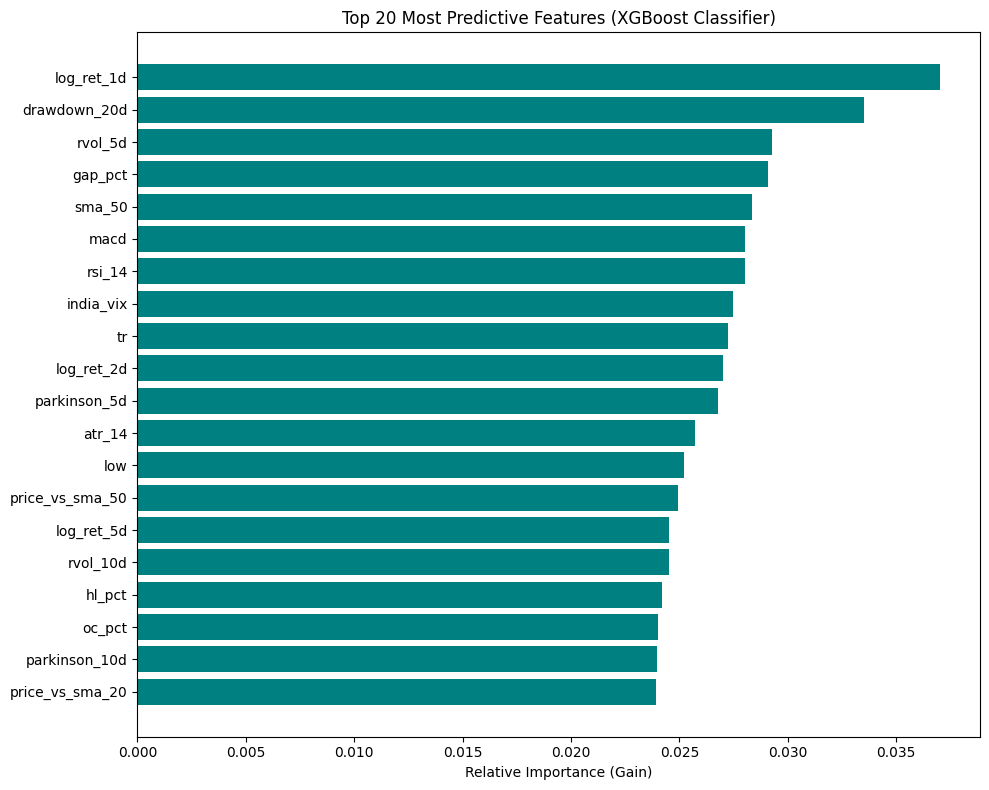

In [11]:
print("\nBlock 4: Plotting Feature Importances...")

plt.figure(figsize=(10, 8))

# Get feature importances from the Classifier
importances = xgb_cls.feature_importances_

# Sort and get the indices for the Top 20 features
indices = np.argsort(importances)[-20:] 

# Create horizontal bar chart
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top 20 Most Predictive Features (XGBoost Classifier)")
plt.xlabel("Relative Importance (Gain)")
plt.tight_layout()
plt.show()